# Assignment 3: Human Activity Recognition Using Smartphones

This notebook reproduces the assignment pipeline for the UCI Human Activity Recognition Using Smartphones dataset. The goal is to predict a person's physical activity from smartphone inertial sensor features.

## Setup

The notebook downloads the dataset if needed, loads the original subject-separated train/test split, trains several classical machine learning models, compares them on the held-out test set, and interprets the best logistic-regression model.

In [1]:
from __future__ import annotations

import zipfile
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

DATASET_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
RANDOM_STATE = 42
ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

In [2]:
def ensure_dataset(root: Path) -> Path:
    data_dir = root / "data"
    data_dir.mkdir(exist_ok=True)
    zip_path = data_dir / "har_smartphones.zip"
    extract_dir = data_dir / "UCI HAR Dataset"

    if extract_dir.exists():
        return extract_dir

    if not zip_path.exists():
        urlretrieve(DATASET_URL, zip_path)

    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(data_dir)

    nested_zip = data_dir / "UCI HAR Dataset.zip"
    if nested_zip.exists() and not extract_dir.exists():
        with zipfile.ZipFile(nested_zip, "r") as archive:
            archive.extractall(data_dir)

    return extract_dir


def load_split(dataset_dir: Path, split: str):
    split_dir = dataset_dir / split
    features = pd.read_csv(split_dir / f"X_{split}.txt", sep=r"\s+", header=None)
    labels = pd.read_csv(split_dir / f"y_{split}.txt", header=None).iloc[:, 0]
    subjects = pd.read_csv(split_dir / f"subject_{split}.txt", header=None).iloc[:, 0]

    feature_names = pd.read_csv(
        dataset_dir / "features.txt", sep=r"\s+", header=None, names=["idx", "name"]
    )["name"].tolist()
    activity_map = pd.read_csv(
        dataset_dir / "activity_labels.txt", sep=r"\s+", header=None, names=["id", "label"]
    )
    label_lookup = dict(zip(activity_map["id"], activity_map["label"]))

    features.columns = feature_names
    labels = labels.map(label_lookup)
    return features, labels, subjects


dataset_dir = ensure_dataset(ROOT)
X_train, y_train, subject_train = load_split(dataset_dir, "train")
X_test, y_test, subject_test = load_split(dataset_dir, "test")

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {X_train.shape[1]}")
y_train.value_counts().sort_index()

Training samples: 7352
Test samples: 2947
Features: 561


,count
0,
LAYING,1407
SITTING,1286
STANDING,1374
WALKING,1226
WALKING_DOWNSTAIRS,986
WALKING_UPSTAIRS,1073


## Model training

We compare a majority-class baseline, logistic regression, k-nearest neighbours, and a decision tree. Hyperparameters are tuned with `GroupKFold`, where the groups are subjects, to avoid subject leakage during validation.

In [3]:
group_cv = GroupKFold(n_splits=5)

models = {
    "baseline": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, solver="lbfgs", random_state=RANDOM_STATE)),
        ]),
        param_grid={"model__C": [0.01, 0.1, 1.0, 10.0]},
        cv=group_cv,
        scoring="accuracy",
        n_jobs=-1,
    ),
    "knn": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
        param_grid={"model__n_neighbors": [3, 5, 7, 11]},
        cv=group_cv,
        scoring="accuracy",
        n_jobs=-1,
    ),
    "decision_tree": GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        param_grid={"max_depth": [10, 20, 30, None], "min_samples_leaf": [1, 2, 5]},
        cv=group_cv,
        scoring="accuracy",
        n_jobs=-1,
    ),
}

results = []
fitted = {}

for name, model in models.items():
    try:
        model.fit(X_train, y_train, groups=subject_train)
    except TypeError:
        model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    fitted[name] = {"model": model, "predictions": predictions}

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "macro_precision": precision_score(y_test, predictions, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, predictions, average="macro", zero_division=0),
        "macro_f1": f1_score(y_test, predictions, average="macro", zero_division=0),
        "best_params": getattr(model, "best_params_", "n/a"),
    })

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_DIR / "model_comparison_from_notebook.csv", index=False)
results_df

,model,accuracy,macro_precision,macro_recall,macro_f1,best_params
0,logistic_regression,0.949779,0.953065,0.948824,0.950026,{'model__C': 0.1}
1,knn,0.886664,0.897235,0.881357,0.883699,{'model__n_neighbors': 11}
2,decision_tree,0.871395,0.871604,0.868341,0.868988,"{'max_depth': 10, 'min_samples_leaf': 5}"
3,baseline,0.182219,0.030370,0.166667,0.051378,n/a


## Best-model evaluation

The best model is selected by test accuracy. We then inspect the classification report and confusion matrix to see which activities are easiest and hardest to distinguish.

Best model: logistic_regression
                    precision    recall  f1-score   support

            LAYING       1.00      0.97      0.99       537
           SITTING       0.96      0.88      0.91       491
          STANDING       0.88      0.96      0.92       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.95      0.95      0.95       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



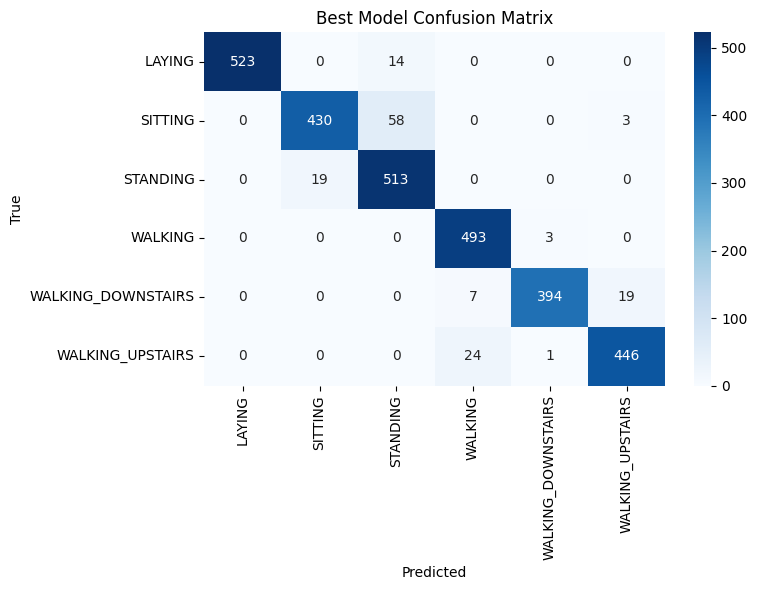

In [4]:
best_name = results_df.loc[0, "model"]
best_predictions = fitted[best_name]["predictions"]
print(f"Best model: {best_name}")
print(classification_report(y_test, best_predictions))

labels = sorted(y_test.unique().tolist())
matrix = confusion_matrix(y_test, best_predictions, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Best Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Logistic-regression feature analysis

To make the solution more interpretable, we inspect the absolute values of the learned logistic-regression coefficients. Features with larger absolute coefficients have a stronger influence on separating the activity classes.

In [5]:
logistic_model = fitted["logistic_regression"]["model"].best_estimator_
classifier = logistic_model.named_steps["model"]
coef_frame = pd.DataFrame(classifier.coef_.T, index=X_train.columns, columns=classifier.classes_)
coef_frame["mean_abs_coef"] = coef_frame.abs().mean(axis=1)
top_features = coef_frame.sort_values("mean_abs_coef", ascending=False).head(20)
top_features.to_csv(RESULTS_DIR / "top_logistic_features_from_notebook.csv")
top_features[["mean_abs_coef"]]

,mean_abs_coef
tBodyGyroJerk-entropy()-X,0.418051
tGravityAcc-mean()-Y,0.296901
tGravityAcc-max()-Y,0.294859
tGravityAcc-min()-Y,0.284850
"angle(Y,gravityMean)",0.254655
fBodyGyro-entropy()-X,0.253059
"tBodyAcc-correlation()-X,Y",0.234196
tGravityAcc-energy()-Y,0.233743
"angle(X,gravityMean)",0.231889
tGravityAcc-max()-X,0.226580


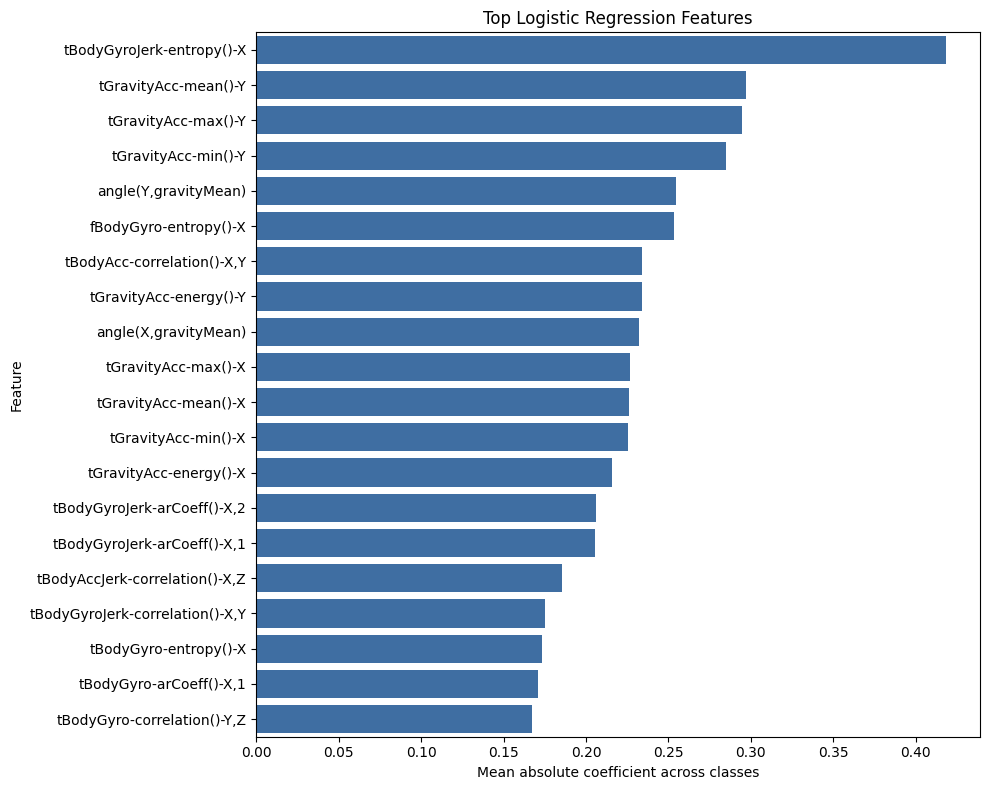

In [6]:
plt.figure(figsize=(10, 8))
sns.barplot(data=top_features.reset_index(), x="mean_abs_coef", y="index", color="#2f6db2")
plt.title("Top Logistic Regression Features")
plt.xlabel("Mean absolute coefficient across classes")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Time-series pipeline (raw inertial signals)

The original HAR data also includes raw inertial windows with shape `(samples, 128, 9)` rather than engineered feature vectors. This section keeps that structure and processes the sequences directly.

We load the `Inertial Signals` files, apply channel-wise temporal normalization using training data statistics, and train a simple 1-nearest-neighbor baseline on the windowed signals.

In [8]:
import numpy as np

SENSOR_FILES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_inertial_signals(dataset_dir: Path, split: str):
    split_dir = dataset_dir / split
    signal_dir = split_dir / "Inertial Signals"

    channels = []
    for sensor in SENSOR_FILES:
        sensor_values = pd.read_csv(
            signal_dir / f"{sensor}_{split}.txt", sep=r"\s+", header=None
        ).to_numpy()
        channels.append(sensor_values)

    X = np.stack(channels, axis=-1)

    activity_map = pd.read_csv(
        dataset_dir / "activity_labels.txt", sep=r"\s+", header=None, names=["id", "label"]
    )
    label_lookup = dict(zip(activity_map["id"], activity_map["label"]))

    y = pd.read_csv(split_dir / f"y_{split}.txt", header=None).iloc[:, 0].map(label_lookup).to_numpy()
    subjects = pd.read_csv(split_dir / f"subject_{split}.txt", header=None).iloc[:, 0].to_numpy()
    return X, y, subjects

X_ts_train, y_ts_train, subject_ts_train = load_inertial_signals(dataset_dir, "train")
X_ts_test, y_ts_test, subject_ts_test = load_inertial_signals(dataset_dir, "test")

print(f"Time-series train shape: {X_ts_train.shape} (samples, timesteps, channels)")
print(f"Time-series test shape: {X_ts_test.shape} (samples, timesteps, channels)")

Time-series train shape: (7352, 128, 9) (samples, timesteps, channels)
Time-series test shape: (2947, 128, 9) (samples, timesteps, channels)


Time-series 1-NN baseline (flattened windows after temporal scaling)
Accuracy: 0.7906
Macro F1: 0.7936


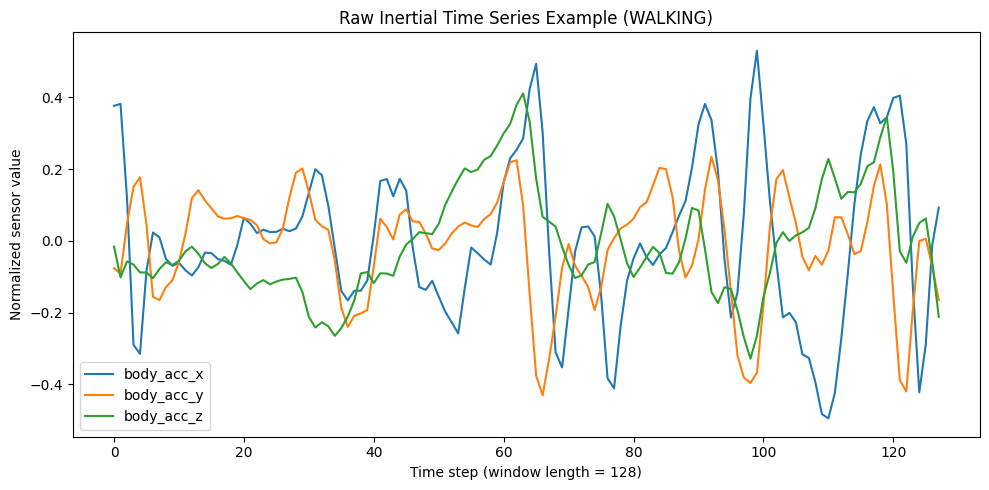

In [9]:
import numpy as np

channel_mean = X_ts_train.mean(axis=(0, 1), keepdims=True)
channel_std = X_ts_train.std(axis=(0, 1), keepdims=True) + 1e-8
X_ts_train_scaled = (X_ts_train - channel_mean) / channel_std
X_ts_test_scaled = (X_ts_test - channel_mean) / channel_std

ts_knn = KNeighborsClassifier(n_neighbors=1)
ts_knn.fit(X_ts_train_scaled.reshape(len(X_ts_train_scaled), -1), y_ts_train)
y_ts_pred = ts_knn.predict(X_ts_test_scaled.reshape(len(X_ts_test_scaled), -1))

print("Time-series 1-NN baseline (flattened windows after temporal scaling)")
print(f"Accuracy: {accuracy_score(y_ts_test, y_ts_pred):.4f}")
print(f"Macro F1: {f1_score(y_ts_test, y_ts_pred, average='macro'):.4f}")

sample_idx = np.where(y_ts_train == "WALKING")[0][0]
time_steps = np.arange(X_ts_train.shape[1])

plt.figure(figsize=(10, 5))
plt.plot(time_steps, X_ts_train[sample_idx, :, 0], label="body_acc_x")
plt.plot(time_steps, X_ts_train[sample_idx, :, 1], label="body_acc_y")
plt.plot(time_steps, X_ts_train[sample_idx, :, 2], label="body_acc_z")
plt.title("Raw Inertial Time Series Example (WALKING)")
plt.xlabel("Time step (window length = 128)")
plt.ylabel("Normalized sensor value")
plt.legend()
plt.tight_layout()
plt.show()

## Time-series deep model (1D CNN)

To better preserve temporal structure, this section trains a compact 1D convolutional neural network on the normalized inertial windows. Unlike flattening, Conv1D learns local motion patterns along time.

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

try:
    import tensorflow as tf
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for the 1D CNN cell. Install with `%pip install tensorflow` and rerun this cell."
    ) from exc

label_encoder = LabelEncoder()
y_ts_train_encoded = label_encoder.fit_transform(y_ts_train)
y_ts_test_encoded = label_encoder.transform(y_ts_test)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(splitter.split(X_ts_train_scaled, y_ts_train_encoded, groups=subject_ts_train))

X_seq_train, X_seq_val = X_ts_train_scaled[train_idx], X_ts_train_scaled[val_idx]
y_seq_train, y_seq_val = y_ts_train_encoded[train_idx], y_ts_train_encoded[val_idx]

tf.keras.utils.set_random_seed(RANDOM_STATE)

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    tf.keras.layers.Conv1D(32, kernel_size=5, activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation="softmax"),
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=3, restore_best_weights=True
 )

history = cnn_model.fit(
    X_seq_train,
    y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=15,
    batch_size=128,
    verbose=0,
    callbacks=[early_stopping],
)

test_prob = cnn_model.predict(X_ts_test_scaled, verbose=0)
y_ts_cnn_pred = label_encoder.inverse_transform(test_prob.argmax(axis=1))

cnn_accuracy = accuracy_score(y_ts_test, y_ts_cnn_pred)
cnn_macro_f1 = f1_score(y_ts_test, y_ts_cnn_pred, average="macro")

print("Time-series 1D CNN")
print(f"Validation best accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Test accuracy: {cnn_accuracy:.4f}")
print(f"Test macro F1: {cnn_macro_f1:.4f}")

Time-series 1D CNN
Validation best accuracy: 0.9600
Test accuracy: 0.9138
Test macro F1: 0.9138


## Discussion

The feature-vector pipeline still performs strongly, with logistic regression reaching high accuracy on engineered statistics. In the new raw-signal pipeline, a simple 1-NN baseline on flattened windows achieves noticeably lower performance, while a compact 1D CNN substantially improves results by learning temporal patterns directly from the `(128, 9)` sequences.

Across both views of the data, `SITTING` and `STANDING` remain among the most confusable activities, while classes such as `LAYING` and `WALKING` are generally easier to separate. This notebook highlights why subject-aware validation and sequence-aware models both matter for trustworthy physical AI evaluation.